In [1]:
from __future__ import annotations

import numpy as np
import sympy as sp
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from config.CEQLConfig import ModelTrainingConfig, CEQLConfig
from src.ComplexEQL import ComplexEQL
from src.utils import set_seed, train
from src.sympy_utils import filter_imaginary_part

# Dataset

In [ ]:
def generate_xy_dataset(
    n_samples: int = 1000,
    x_range: tuple[float, float] = (-5.0, 5.0),   # x>0 to keep x^y real
    y_range: tuple[float, float] = (-5.0, 5.0),
):
    """
    Generate dataset for f(x, y) = x^y.
    We restrict x>0 so that x^y is real-valued for real y.
    Also filter out samples with |f| > 20 to avoid huge targets.
    """
    # sample x, y independently
    x = np.random.uniform(*x_range, size=(n_samples, 1))
    y = np.random.uniform(*y_range, size=(n_samples, 1))

    # compute function: f = x^y
    f = np.sin(2*y) # shape (N,1)

    # filter out non-finite values (just in case) and |f| > 20
    mask = np.isfinite(f) & (np.abs(f) <= 100.0)
    x = x[mask]
    y = y[mask]
    f = f[mask]

    # reshape again so concatenation never fails
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)
    f = f.reshape(-1, 1)

    # concatenate safely: X = [x, y]
    X = np.concatenate([x, y], axis=1)

    return torch.from_numpy(X).float(), torch.from_numpy(f).float()

# Training

In [3]:
# -------------------------
# Config and setup
# -------------------------
mcfg = ModelTrainingConfig()
ncfg = CEQLConfig()

device = torch.device(mcfg.device)
set_seed(42)

# -------------------------
# Data
# -------------------------
X, y = generate_xy_dataset()
assert torch.isfinite(X).all(), "X contains NaN/Inf"
assert torch.isfinite(y).all(), "y contains NaN/Inf"
dataset = TensorDataset(X, y)
dataloader = DataLoader(
    dataset,
    batch_size=mcfg.train_batch_size,
    shuffle=True,
    drop_last=False,
)

# -------------------------
# Model, loss, optimizer, scheduler
# -------------------------
model = ComplexEQL(ncfg).to(device)
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=mcfg.lr)

scheduler = None
if getattr(mcfg, "scheduler", None) == "ReduceLROnPlateau":
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, **mcfg.schedulerparams
    )
elif getattr(mcfg, "scheduler", None) is None:
    scheduler = None
else:
    raise ValueError(f"Unknown scheduler: {mcfg.scheduler}")

# -------------------------
# Training (cycle-based; scheduler is stepped only in final 10000 epochs inside train)
# -------------------------
model, (sl0_weights, al_weights, imaginary_out_losses, data_losses) = train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    cfg=mcfg,
    device=device,
    scheduler=scheduler,
)

# -------------------------
# Symbolic readout
# -------------------------
x_sym, y_sym = sp.symbols("x y")
symbolic_expr = model.get_symbolic_expression([x_sym, y_sym], rounding_decimals=2)
print("\nDiscovered expression:")
print(symbolic_expr)

Random seed set as 42
[POST_RAMP | Epoch 1 | cycle=0] lr=1.00e-03, total=3.6004e-01, data=3.5940e-01, sparsity_reg=0.0000e+00, imag_w=6.3974e-04, r=0.1000, active_edges=5
[POST_RAMP | Epoch 500 | cycle=0] lr=1.00e-03, total=1.6755e-01, data=1.6753e-01, sparsity_reg=0.0000e+00, imag_w=2.1021e-05, r=0.1449, active_edges=5
[POST_RAMP | Epoch 1000 | cycle=0] lr=1.00e-03, total=1.6749e-01, data=1.6749e-01, sparsity_reg=0.0000e+00, imag_w=8.9923e-08, r=0.1899, active_edges=5
[POST_RAMP | Epoch 1500 | cycle=0] lr=1.00e-03, total=1.6740e-01, data=1.6740e-01, sparsity_reg=0.0000e+00, imag_w=2.6339e-11, r=0.2349, active_edges=5
[POST_RAMP | Epoch 2000 | cycle=0] lr=1.00e-03, total=1.6729e-01, data=1.6729e-01, sparsity_reg=0.0000e+00, imag_w=2.5582e-16, r=0.2799, active_edges=5
[POST_RAMP | Epoch 2500 | cycle=0] lr=1.00e-03, total=1.6720e-01, data=1.6720e-01, sparsity_reg=0.0000e+00, imag_w=2.5969e-23, r=0.3249, active_edges=5
[POST_RAMP | Epoch 3000 | cycle=0] lr=1.00e-03, total=1.6714e-01, data

In [4]:
x_sym, y_sym = sp.symbols("x y")
symbolic_expr = model.get_symbolic_expression([x_sym, y_sym], rounding_decimals=5)
# symbolic_expr = filter_imaginary_part(symbolic_expr, [x_sym, y_sym])
print(symbolic_expr)

0.00644*x + 0.00821*y - 0.10735*sin(0.84788*x + 2.04538*y)


In [5]:
symbolic_expr

0.00644*x + 0.00821*y - 0.10735*sin(0.84788*x + 2.04538*y)

In [6]:
sp.simplify(symbolic_expr)

0.00644*x + 0.00821*y - 0.10735*sin(0.84788*x + 2.04538*y)

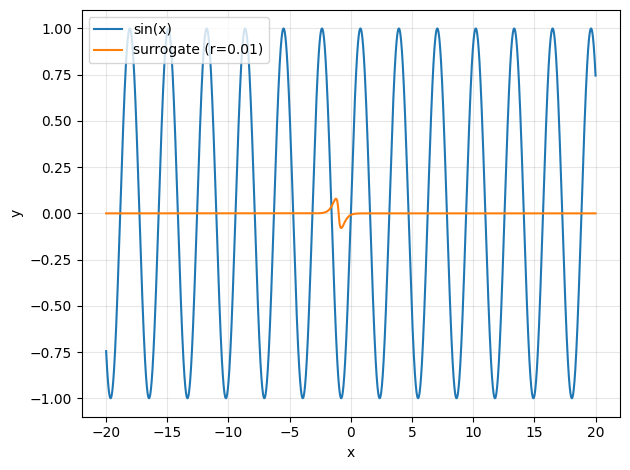

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def sin_surrogate_np(x: np.ndarray, r: float) -> np.ndarray:
    # Match the torch code: u = x.real, phi = |u|, damp = exp(log(r)*phi), y = damp*sin(u)
    u = np.real(x).astype(np.float64, copy=False)
    r = float(np.clip(r, 1e-12, 1.0))
    damp = np.exp(np.log(r) * np.abs(u))
    return damp * np.sin(u)

# -------------------------
# Plot: surrogate vs. sin
# -------------------------
x = np.linspace(-20.0, 20.0, 4000)
r = 0.01  # change this (e.g., 0.99, 0.95, 0.8, 0.5)

y_sur = sin_surrogate_np(x+1, r)
y_sin = np.sin(2*x)

plt.figure()
plt.plot(x, y_sin, label="sin(x)")
plt.plot(x, -y_sur, label=f"surrogate (r={r})")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Visualize the predictions

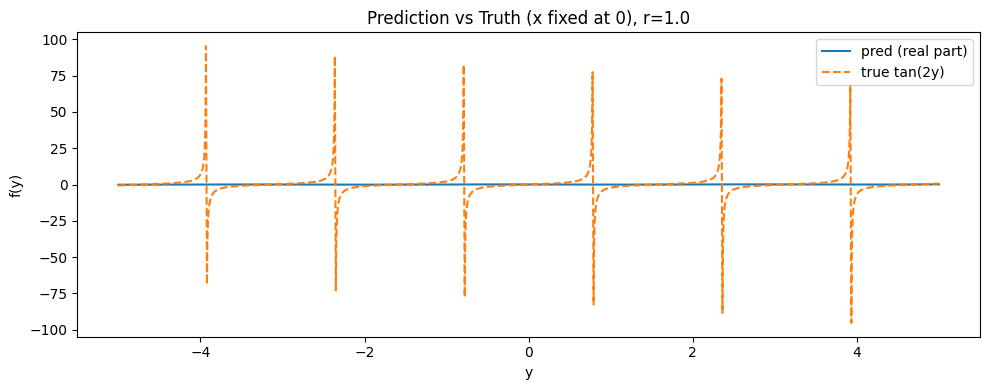

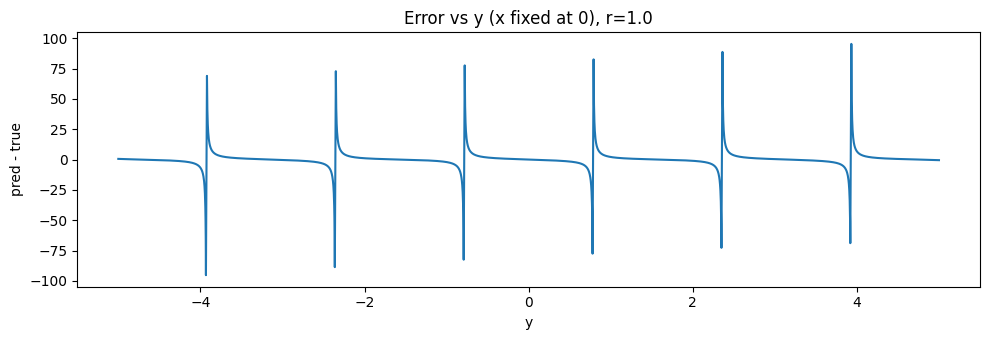

In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ----------------------------
# Domain (match dataset)
# ----------------------------
y_min, y_max = -5.0, 5.0
n = 4000
y_line = np.linspace(y_min, y_max, n)

# x is irrelevant for f(x,y)=tan(2y), but the model still expects 2 inputs.
# Use a fixed x0.
x0 = 0.0
X_line = np.stack([np.full_like(y_line, x0), y_line], axis=1)
X_line_t = torch.from_numpy(X_line).float().to(device)

# ----------------------------
# Op params (r required by trig surrogates)
# ----------------------------
r_vis = 1.0
op_params_vis = {"sin": {"r": r_vis}, "cos": {"r": r_vis}, "tan": {"r": r_vis}}

# ----------------------------
# Predict
# ----------------------------
model.eval()
with torch.no_grad():
    pred = model(X_line_t, op_params=op_params_vis)  # complex (N,1)
    pred_y = pred.real.detach().cpu().numpy().reshape(-1)

# ----------------------------
# Ground truth: tan(2y)
# Apply same filtering as dataset: finite and |f|<=100
# ----------------------------
true_y = np.tan(2.0 * y_line)
mask = np.isfinite(true_y) & (np.abs(true_y) <= 100.0)

y_plot = y_line[mask]
pred_plot = pred_y[mask]
true_plot = true_y[mask]
err_plot = pred_plot - true_plot

# ----------------------------
# 2D plots
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(y_plot, pred_plot, label="pred (real part)")
plt.plot(y_plot, true_plot, linestyle="--", label="true tan(2y)")
plt.xlabel("y")
plt.ylabel("f(y)")
plt.title(f"Prediction vs Truth (x fixed at {x0:g}), r={r_vis}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3.5))
plt.plot(y_plot, err_plot)
plt.xlabel("y")
plt.ylabel("pred - true")
plt.title(f"Error vs y (x fixed at {x0:g}), r={r_vis}")
plt.tight_layout()
plt.show()


# Visualize weights

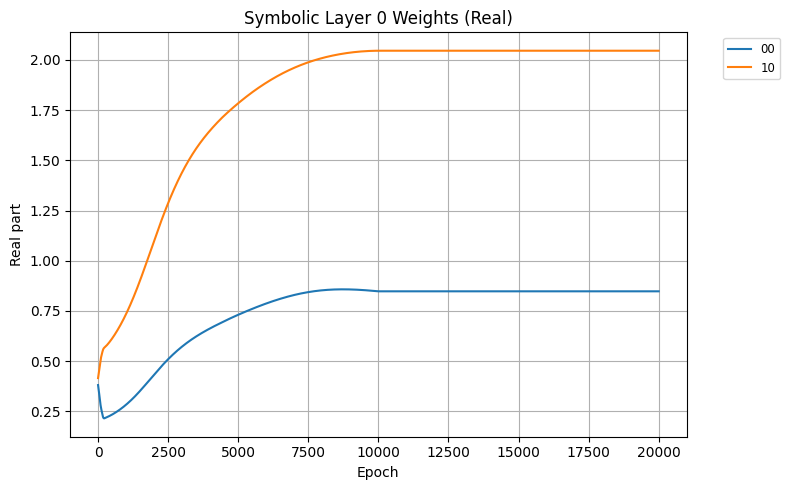

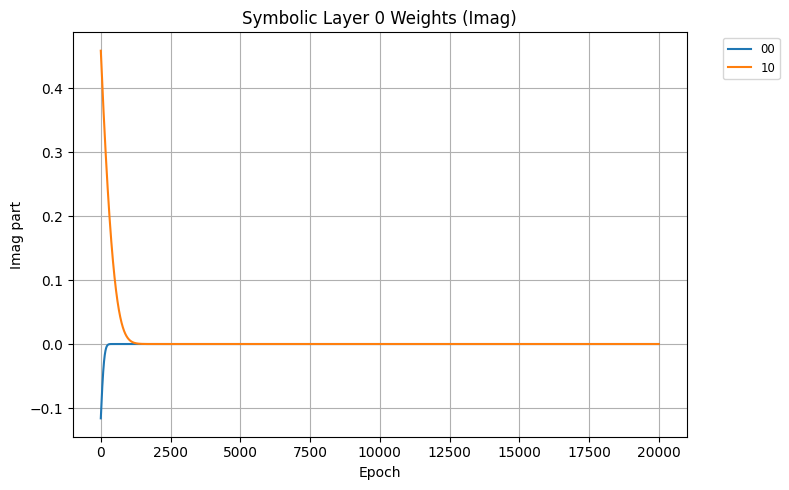

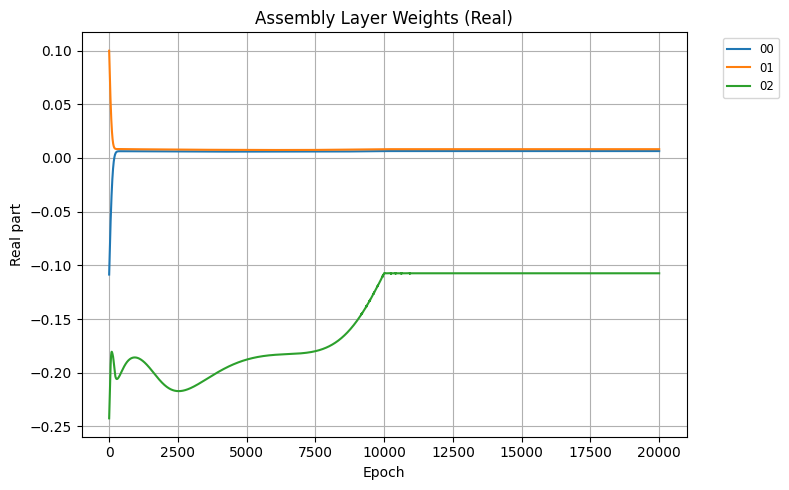

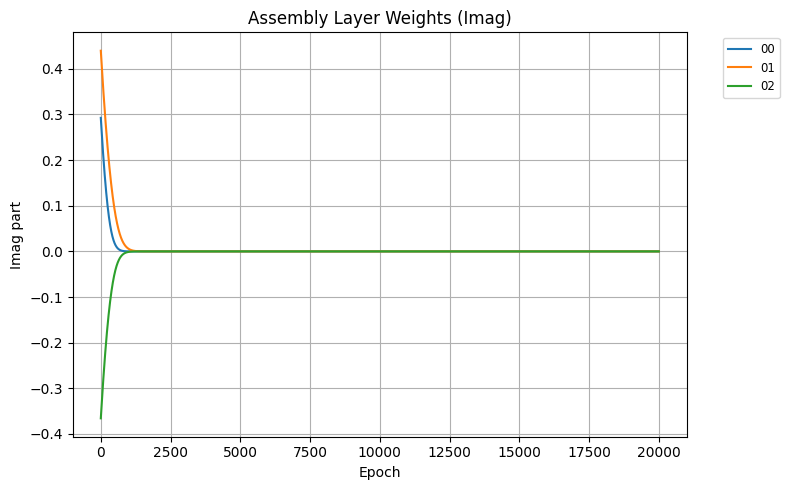

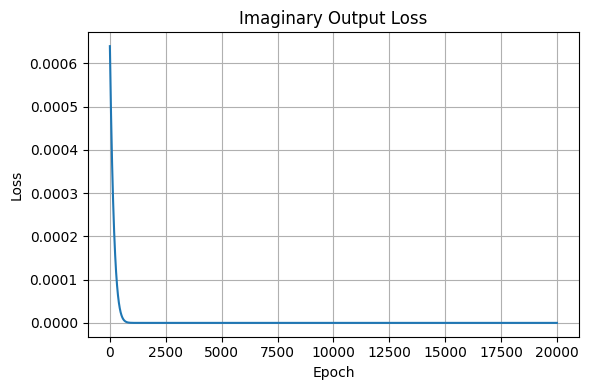

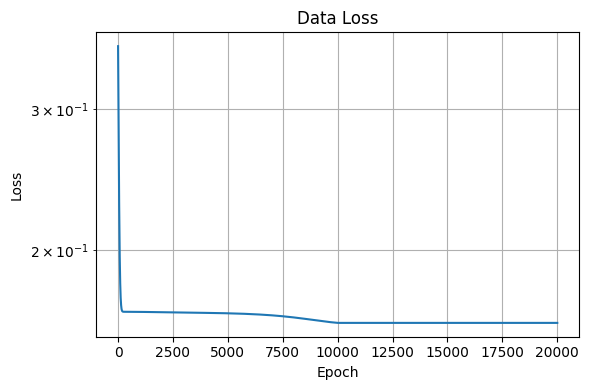

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Helper: flatten list of complex numpy arrays
# ----------------------------
def flatten_complex_list(weight_list):
    flat = [w.reshape(-1) for w in weight_list]
    mat = np.vstack(flat)
    return mat.real, mat.imag


# ==========================================================
# 1) Symbolic layer 0 weights
# ==========================================================
sl0_real, sl0_imag = flatten_complex_list(sl0_weights)
epochs0 = np.arange(len(sl0_real))

in_dim0, out_dim0 = sl0_weights[0].shape
labels_sl0 = [f"{i}{j}" for i in range(in_dim0) for j in range(out_dim0)]

# --- real part ---
plt.figure(figsize=(8, 5))
for k in range(sl0_real.shape[1]):
    plt.plot(epochs0, sl0_real[:, k], label=labels_sl0[k])
plt.title("Symbolic Layer 0 Weights (Real)")
plt.xlabel("Epoch")
plt.ylabel("Real part")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.tight_layout()

# --- imaginary part ---
plt.figure(figsize=(8, 5))
for k in range(sl0_imag.shape[1]):
    plt.plot(epochs0, sl0_imag[:, k], label=labels_sl0[k])
plt.title("Symbolic Layer 0 Weights (Imag)")
plt.xlabel("Epoch")
plt.ylabel("Imag part")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.tight_layout()


# ==========================================================
# 2) Assembly layer weights
# ==========================================================
al_real, al_imag = flatten_complex_list(al_weights)
epochs_al = np.arange(len(al_real))

labels_al = [f"{i:02d}" for i in range(al_real.shape[1])]

# --- real part ---
plt.figure(figsize=(8, 5))
for k in range(al_real.shape[1]):
    plt.plot(epochs_al, al_real[:, k], label=labels_al[k])
plt.title("Assembly Layer Weights (Real)")
plt.xlabel("Epoch")
plt.ylabel("Real part")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.tight_layout()

# --- imaginary part ---
plt.figure(figsize=(8, 5))
for k in range(al_imag.shape[1]):
    plt.plot(epochs_al, al_imag[:, k], label=labels_al[k])
plt.title("Assembly Layer Weights (Imag)")
plt.xlabel("Epoch")
plt.ylabel("Imag part")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
plt.tight_layout()


# ==========================================================
# 3) Losses
# ==========================================================
imag_losses = np.array(imaginary_out_losses)
data_losses = np.array(data_losses)

# --- imaginary_out_losses ---
plt.figure(figsize=(6, 4))
plt.plot(imag_losses)
plt.title("Imaginary Output Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
# plt.yscale("log")
plt.tight_layout()

# --- data_losses (log scale) ---
plt.figure(figsize=(6, 4))
plt.plot(data_losses)
plt.title("Data Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")    # <<<<<< LOG SCALE HERE
plt.grid(True, which="both")
plt.tight_layout()

plt.show()
